# 1. Restricting ligand–receptor methods with spatial proximity

Standard cell–cell communication methods — CellPhoneDB, NATMI, SingleCellSignalR, and
LIANA's consensus of them — take an expression matrix and a cell-type label, and ask:
*given that cell type A expresses the ligand and cell type B the receptor, how strong
and how specific is that interaction?* They were designed for dissociated scRNA-seq,
so they know nothing about geometry: two cell types at opposite ends of the tissue
score exactly like two cell types sitting on top of each other.

With single-cell resolution spatial data we can do better. Here we:

1. measure how close each pair of cell types actually is, and
2. use that proximity to **restrict and re-weight** a standard LR method.

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import liana as li

import warnings
warnings.filterwarnings("ignore")

adata = sc.read_h5ad("data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layer

## Cell type spatial proximity

This method finds pairwise proximity between cell types using minimum nearest-neighbor
distances in spatial coordinates (inspired by
[CellChatv2](https://www.nature.com/articles/s41596-024-01045-4)) and computes a
proximity score using a kernel function (e.g. Gaussian). <br>
Proximity scores are used for weighting ligand–receptor interactions by how strongly the
corresponding cell types co-localize across the whole slide.

Specifically, for each cell type pair $(A, B)$:

1. **Distance calculation**: Find nearest neighbor (euclidean) distances $d_i$ for each cell $i \in A$ to cells in $B$
   - For self-interactions $(A = A)$, exclude the cell itself (use 2nd nearest neighbor)

2. **Aggregation**: Compute trimmed mean distance
   $$\bar{d}_{A,B} = \text{trim\_mean}(\{d_i\}, \alpha)$$
   where $\alpha$ is the trim fraction (default: 0.1)

3. **Proximity score**: Apply kernel function (e.g. Gaussian $K(d, \sigma) = \exp\left(-\frac{d^2}{2\sigma^2}\right)$) to mean distance, where $\sigma$ is the bandwidth parameter controlling the spatial scale of proximity.
   $$p_{A,B} = K(\bar{d}_{A,B}, \sigma)$$

4. **Multiply** each ligand–receptor interaction score between cell types $A$ and $B$ by proximity score $p_{A,B}$ to get proximity-weighted interaction scores.

### Calculate cell pair proximity on its own

In [2]:
pair_proximity = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian', bandwidth=100, spatial_key='X_spatial_coords', verbose=True)

Computing cell type proximities: 100%|██████████| 484/484 [00:06<00:00, 73.25it/s]


**interacting** is a binary flag: **0** if too few cells are co-localized across two cell
types for them to be considered as interacting, and 1 otherwise. <br>
**proximity** is a spatial co-localization weight between two cell types, bound between 0
and 1 (based on the `bandwidth`). Higher values mean closer proximity and stronger
interactions; lower values reflect weaker or no spatial co-localization.

In [3]:
pair_proximity.sort_values('proximity', ascending=True).head(3)

,source,target,mean_distance,interacting,proximity
133,endothelial cell,cholinergic neuron,4022.129117,0,0.0
419,smooth muscle cell,cholinergic neuron,3877.382295,0,0.0
177,glutamatergic neuron,cholinergic neuron,4252.846167,0,0.0


<Axes: xlabel='target', ylabel='source'>

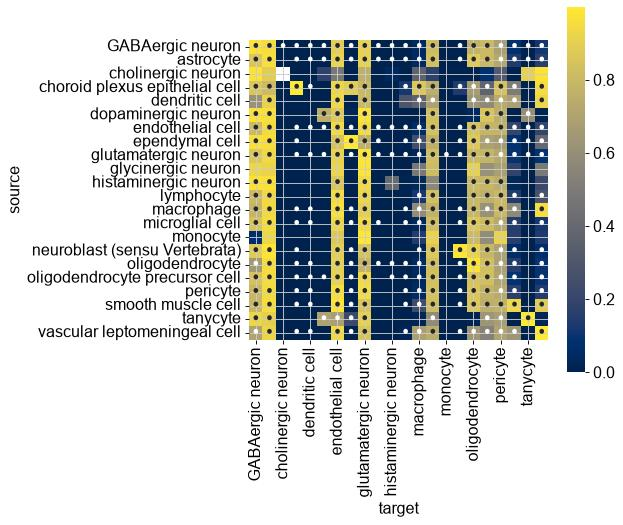

In [4]:
plt.figure(figsize=(6, 6))
proximity = 'proximity'
interacting = 'interacting'
sns.heatmap(
    data=pair_proximity.pivot(index='source', columns='target', values=proximity),
    annot=pair_proximity.pivot(index='source', columns='target', values=interacting).fillna(0).astype(int).replace({1: '•', 0: ''}),
    fmt='',
    annot_kws={'fontfamily': 'DejaVu Sans'},
    cmap='cividis',
    square=True
)

The heatmap indicates that e.g. the **smooth muscle cell** and **tanycyte** pair did not
meet the interaction criteria (`interacting == 0`). The spatial plot below shows why:
despite the abundance of smooth muscle cells (n = 4314), tanycytes are highly localized,
lacking sufficient proximity to smooth muscle cells to pass the filter.

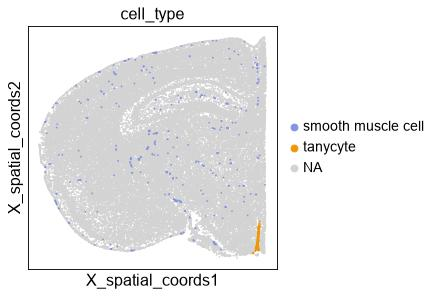

In [5]:
sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color="cell_type",
    groups=["smooth muscle cell", "tanycyte"],
    s=10,
)

## Weight LR inference by cell type pair spatial proximity

`li.mt.rank_aggregate` runs several standard LR methods and aggregates their rankings.
We run it **twice** on the same data — once ignoring space, once passing `spatial_key`
so that every interaction score is multiplied by the proximity of its cell type pair.
The difference between the two rankings is the point of this notebook.

In [6]:
# (a) the standard, non-spatial run -- what you would get from dissociated scRNA-seq
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     key_added='liana_res_plain',
                     )

Using resource `mouseconsensus`.
Using `.X`!
0.83 of entities in the resource are missing from the data.
100%|██████████| 1000/1000 [00:01<00:00, 711.38it/s]


Generating ligand-receptor stats for 51535 samples and 113 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [7]:
# (b) the same run, restricted by how close the cell types actually are
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     spatial_key='X_spatial_coords',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     spatial_kwargs={'kernel':'gaussian', 'bandwidth':100},
                     )

Using resource `mouseconsensus`.
Using `.X`!
0.83 of entities in the resource are missing from the data.
100%|██████████| 1000/1000 [00:01<00:00, 708.68it/s]


Generating ligand-receptor stats for 51535 samples and 113 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [8]:
adata.uns["liana_res"].sort_values(['magnitude_rank', 'lrscore'], ascending=(True, False)).head(3)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
5640,dopaminergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,3.086861,3.484807,0.764706,0.766125,3.216962,0.0,10.531641,1.213030,1.966449,0.043205,0.857040,7.822985e-07,1.577422e-11
24640,vascular leptomeningeal cell,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,2.513404,4.076341,0.526579,0.826147,3.110099,0.0,9.670934,1.565816,2.773729,0.023733,0.823765,3.439104e-06,1.261937e-10
11135,histaminergic neuron,GABAergic neuron,Hdc,Hrh3,Hdc,Hrh3,4.415166,1.848131,0.857143,0.448671,3.053615,0.0,7.956484,2.980445,3.313899,0.063879,0.838101,4.507768e-10,1.796782e-10


### What did the spatial weighting change?

In [9]:
keys = ["source", "target", "ligand_complex", "receptor_complex"]

plain = adata.uns["liana_res_plain"][keys + ["magnitude_rank"]]
prox = adata.uns["liana_res"][keys + ["magnitude_rank"]]

cmp = plain.merge(prox, on=keys, suffixes=("_plain", "_prox"))
cmp["pos_plain"] = cmp["magnitude_rank_plain"].rank(method="first").astype(int)
cmp["pos_prox"] = cmp["magnitude_rank_prox"].rank(method="first").astype(int)
cmp["shift"] = cmp["pos_plain"] - cmp["pos_prox"]

print(f"{len(cmp)} interactions ranked by both\n")
print("Demoted the most by spatial weighting (distant cell type pairs):")
print(cmp.nsmallest(5, "shift")[keys + ["pos_plain", "pos_prox"]].to_string(index=False))

25683 interactions ranked by both

Demoted the most by spatial weighting (distant cell type pairs):
              source               target ligand_complex receptor_complex  pos_plain  pos_prox
histaminergic neuron histaminergic neuron            Hdc             Hrh3          1     15923
    endothelial cell             tanycyte            Fn1             Tshr          5     15924
histaminergic neuron   glycinergic neuron            Hdc             Hrh3          7     15925
 dopaminergic neuron histaminergic neuron        Col18a1             Gpc4         10     15926
 dopaminergic neuron   glycinergic neuron          Efna5            Epha7         11     15927


Interactions between cell types that are far apart on the slide get pushed down the
ranking, even though their expression evidence is unchanged. This is exactly the
failure mode that a non-spatial method cannot see.

### Visualise the proximity-weighted result

Interactions from **glutamatergic neurons** to various target cell types:

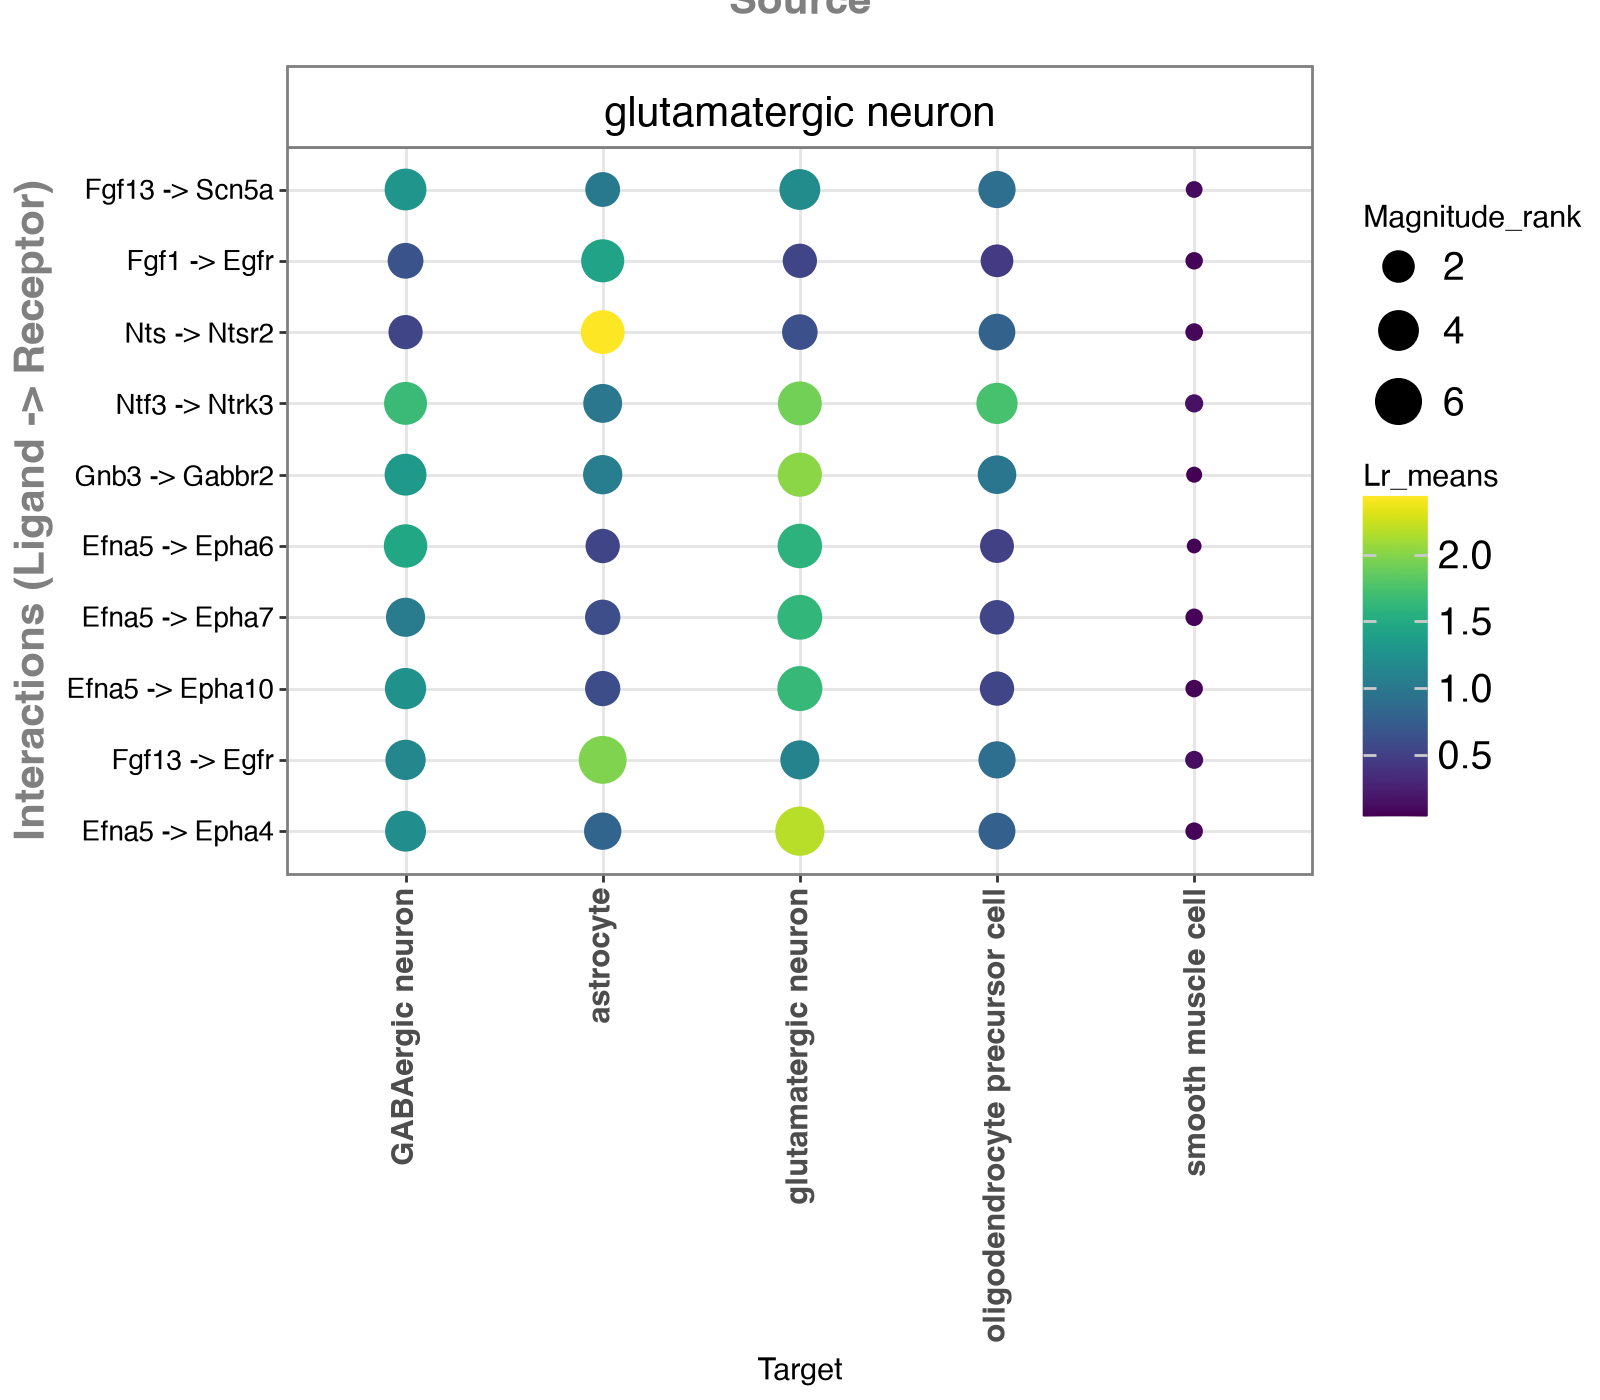

In [10]:
li.pl.dotplot(adata = adata,
              colour='lr_means',
              size='magnitude_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=["glutamatergic neuron"],
              target_labels=["glutamatergic neuron", "GABAergic neuron", "astrocyte", "oligodendrocyte precursor cell", "smooth muscle cell"],
              top_n=10,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

A specific interaction of interest, across all cell type pairs:

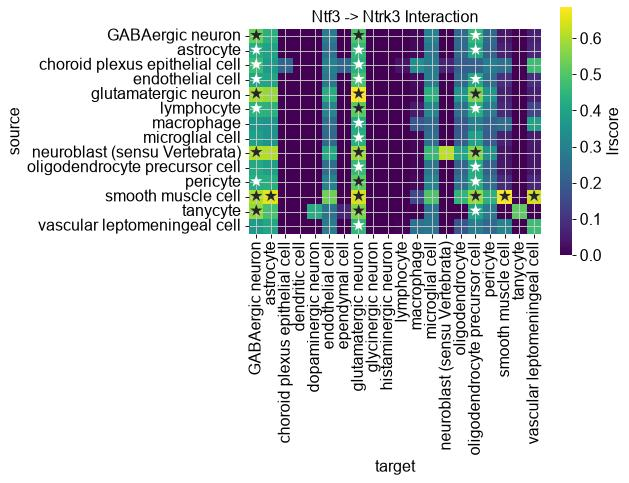

In [11]:
df = adata.uns['liana_res']
interaction_df = df[(df['ligand_complex'] == 'Ntf3') & (df['receptor_complex'] == 'Ntrk3')].copy()
# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    data= interaction_df.pivot_table(index='source', columns='target', values='lrscore'),
    annot=interaction_df.pivot(index='source', columns='target', values='specificity_rank').map(lambda x: '★' if x < 0.05 else ('★★' if x < 0.01 else '')),
    annot_kws={'fontfamily': 'DejaVu Sans'},
    fmt='',
    square=True,
    cmap='viridis',
    cbar_kws={'label': 'lrscore'}
)
plt.title('Ntf3 -> Ntrk3 Interaction')
plt.tight_layout()
plt.show()

---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — How much does the bandwidth matter?**

`bandwidth=100` (µm) decides how quickly proximity decays with distance — and therefore
which cell type pairs count as interacting at all.

Re-run `li.pp.spatial_pair_proximity` with `bandwidth=30` and `bandwidth=300`, and count
how many cell type pairs are flagged `interacting == 1` in each case.

Which bandwidth would you defend for a MERFISH brain section, and on what grounds?
</div>

In [12]:
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    # ... how many pairs are interacting? what is the median proximity?
    print(bw)

30
100
300


<details>
<summary><b>▶ Solution</b></summary>

```python
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    print(f"bandwidth={bw:>4} µm | interacting pairs: {int(pp['interacting'].sum()):>3}/{len(pp)}"
          f" | median proximity: {pp['proximity'].median():.3f}")
```

A small bandwidth admits only cell types that are essentially touching; a large one lets
almost every pair through and the weighting stops discriminating.

There is no single correct answer, but there is a defensible one: the bandwidth should
reflect the **signalling range you care about**, not the size of the tissue. Juxtacrine
and short-range paracrine signalling operates over roughly one to a few cell diameters
(~10–50 µm here), so a bandwidth in that range is biologically motivated. `100` µm is a
permissive default — it keeps genuinely neighbouring populations while still zeroing out
cell types in different anatomical compartments.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick a different ligand–receptor pair, or a different sender cell type, from the ranked
table and remake the heatmap above.

```python
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)
```

Does your interaction look plausible given the proximity heatmap from earlier — i.e. are
its top cell type pairs ones that actually co-localize?
</div>

In [13]:
# your turn
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
5640,dopaminergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,3.086861,3.484807,0.764706,0.766125,3.216962,0.0,10.531641,1.213030,1.966449,0.043205,0.857040,7.822985e-07,1.577422e-11
24640,vascular leptomeningeal cell,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,2.513404,4.076341,0.526579,0.826147,3.110099,0.0,9.670934,1.565816,2.773729,0.023733,0.823765,3.439104e-06,1.261937e-10
11135,histaminergic neuron,GABAergic neuron,Hdc,Hrh3,Hdc,Hrh3,4.415166,1.848131,0.857143,0.448671,3.053615,0.0,7.956484,2.980445,3.313899,0.063879,0.838101,4.507768e-10,1.796782e-10
4377,choroid plexus epithelial cell,vascular leptomeningeal cell,Sostdc1,Lrp4,Sostdc1,Lrp4,3.331656,2.442200,0.729839,0.530331,2.757940,0.0,7.773029,2.176535,2.792217,0.054745,0.820950,5.381457e-09,2.464721e-10
5263,dopaminergic neuron,GABAergic neuron,Efna5,Epha6,Efna5,Epha6,3.086861,2.482132,0.764706,0.588072,2.716959,0.0,7.476156,1.215726,1.690484,0.056305,0.834920,4.617088e-06,3.280544e-10
24363,vascular leptomeningeal cell,astrocyte,Spp1,S1pr1,Spp1,S1pr1,2.513404,4.552614,0.526579,0.900674,3.265996,0.0,10.577768,1.631518,3.013585,0.025959,0.812308,1.560201e-06,5.414993e-10
5638,dopaminergic neuron,glutamatergic neuron,Efna5,Epha10,Efna5,Epha10,3.086861,2.393576,0.764706,0.568773,2.682782,0.0,7.233767,1.183575,2.115481,0.063054,0.835529,3.517759e-07,6.763195e-10
17466,oligodendrocyte,astrocyte,Fgf1,Egfr,Fgf1,Egfr,3.413700,2.174973,0.691550,0.485993,2.659000,0.0,7.065110,0.963373,2.416505,0.023545,0.812373,3.514295e-06,1.009550e-09
5642,dopaminergic neuron,glutamatergic neuron,Efna5,Epha7,Efna5,Epha7,3.086861,2.341524,0.764706,0.552636,2.657302,0.0,7.076459,1.180983,2.152016,0.046011,0.834177,3.666271e-07,1.210918e-09
5641,dopaminergic neuron,glutamatergic neuron,Efna5,Epha6,Efna5,Epha6,3.086861,2.269548,0.764706,0.536847,2.622068,0.0,6.858935,1.166213,2.064033,0.051657,0.832239,3.975706e-07,1.971777e-09


<details>
<summary><b>▶ Solution</b></summary>

Any well-ranked pair works. The check that matters is consistency: because every score
was multiplied by `proximity`, a highly ranked interaction *cannot* involve a cell type
pair with proximity near zero. So the top of this table should only ever contain pairs
that look bright in the proximity heatmap.

If you pick an interaction and find its best cell type pair is one you know to be
anatomically separated, that is a sign the proximity bandwidth is too permissive — which
is exactly what Exercise 1 was probing.

</details>

---

**Next:** notebook 02 asks a sharper question — not *are these cell types near each other
on average*, but *at what distance* is a given interaction enriched.